# Credit Risk Segmentation: PD Modelling + FICO-Based Rating Buckets

**Methodology demonstration** built around the approach used in JPMorgan Chase's
*Quantitative Research* virtual simulation (Forage): estimate a borrower-level
probability of default (PD), then compress the FICO score distribution into a
small number of statistically distinct rating buckets using log-likelihood
optimal bucketing (solved via dynamic programming).

> **Data disclosure:** All data in this notebook is **synthetically generated**
> (seeded, reproducible — see `data/generate_synthetic_data.py`). It mirrors the
> *structure* of a typical retail-credit dataset but contains no real,
> proprietary, or confidential information from JPMorgan Chase, Forage, or any
> other institution. It exists solely to demonstrate the analytical method on
> a dataset that can be shared publicly.

**Contents**
1. Data overview
2. Exploratory analysis
3. Probability-of-default (PD) model — logistic regression
4. FICO rating buckets — dynamic-programming log-likelihood optimization
5. Results & business interpretation


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

from fico_bucketing import fit_fico_buckets, assign_rating

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 100)

df = pd.read_csv("../data/synthetic_loan_data.csv")
df["debt_to_income"] = df["total_debt_outstanding"] / df["income"]
print(f"{len(df):,} borrowers | {df['default'].mean():.2%} portfolio default rate")
df.head()


50,000 borrowers | 13.34% portfolio default rate


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default,debt_to_income
0,1,1,23948.27,27939.18,78148.13,6,677,0,0.357516
1,2,3,3260.18,6142.59,64301.62,6,603,0,0.095528
2,3,1,12786.11,14989.62,51342.96,6,701,0,0.291951
3,4,3,8557.80,21614.78,37857.34,8,712,0,0.570953
4,5,2,40808.11,46318.79,137561.64,3,553,0,0.336713


## 1. Data overview

Eight fields per borrower: identifiers, credit-line count, existing loan and total debt balances, income, employment tenure, FICO score, and the realized default outcome (1 = defaulted).

In [2]:
df.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
customer_id,50000.0,25000.50,14433.90,1.00,12500.75,25000.50,37500.25,50000.00
credit_lines_outstanding,50000.0,2.29,1.51,0.00,1.00,2.00,3.00,12.00
loan_amt_outstanding,50000.0,18435.75,14087.79,543.62,8405.92,15022.02,24406.98,236415.66
total_debt_outstanding,50000.0,24057.33,14932.19,708.41,13565.06,20892.46,30946.87,241534.96
income,50000.0,61361.78,32731.44,6519.81,38725.73,54154.87,75813.80,430247.75
years_employed,50000.0,5.00,2.24,0.00,3.00,5.00,6.00,19.00
fico_score,50000.0,659.96,55.12,419.00,623.00,660.00,697.00,850.00
default,50000.0,0.13,0.34,0.00,0.00,0.00,0.00,1.00
debt_to_income,50000.0,0.42,0.20,0.05,0.27,0.41,0.54,3.67


## 2. Exploratory analysis

Two checks before modelling: (a) do the features correlate in the directions we'd expect economically, and (b) is FICO score visibly separating defaulters from non-defaulters?

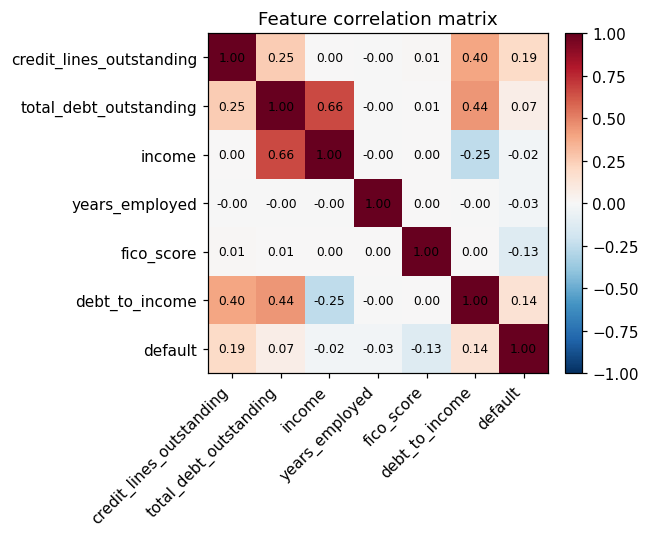

In [3]:
corr = df[["credit_lines_outstanding","total_debt_outstanding","income",
           "years_employed","fico_score","debt_to_income","default"]].corr()

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()


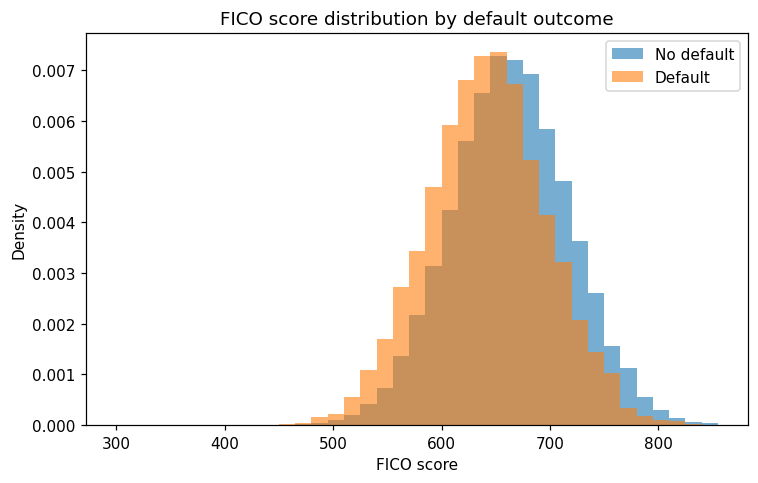

In [4]:
fig, ax = plt.subplots(figsize=(7,4.5))
bins = np.arange(300, 860, 15)
ax.hist(df.loc[df["default"]==0, "fico_score"], bins=bins, alpha=0.6, label="No default", density=True)
ax.hist(df.loc[df["default"]==1, "fico_score"], bins=bins, alpha=0.6, label="Default", density=True)
ax.set_xlabel("FICO score"); ax.set_ylabel("Density")
ax.set_title("FICO score distribution by default outcome")
ax.legend()
plt.tight_layout()
plt.show()


## 3. Probability-of-default (PD) model

A logistic regression on four standardized features (`credit_lines_outstanding`, `debt_to_income`, `years_employed`, `fico_score`), with balanced class weights since defaults are the minority class (~13% of the portfolio).

In [5]:
features = ["credit_lines_outstanding", "debt_to_income", "years_employed", "fico_score"]
X, y = df[features], df["default"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

pd_model = LogisticRegression(max_iter=1000, class_weight="balanced")
pd_model.fit(X_train_s, y_train)

proba = pd_model.predict_proba(X_test_s)[:, 1]
pred = pd_model.predict(X_test_s)

auc = roc_auc_score(y_test, proba)
print(f"Test AUC: {auc:.3f}\n")
print(classification_report(y_test, pred, digits=3, target_names=["No default", "Default"]))

coef_table = pd.DataFrame({
    "feature": features,
    "standardized_coef": pd_model.coef_[0].round(3),
})
print(coef_table.to_string(index=False))


Test AUC: 0.701

              precision    recall  f1-score   support

  No default      0.921     0.667     0.774     10832
     Default      0.226     0.630     0.332      1668

    accuracy                          0.662     12500
   macro avg      0.574     0.649     0.553     12500
weighted avg      0.829     0.662     0.715     12500

                 feature  standardized_coef
credit_lines_outstanding              0.446
          debt_to_income              0.212
          years_employed             -0.104
              fico_score             -0.421


An AUC around 0.70 is realistic for a PD model built on application-level features alone (no bureau tradeline history, no macro variables) — real retail-credit PD models commonly sit in the 0.65-0.80 AUC range before adding richer bureau data. The coefficient signs all match economic intuition: more open credit lines, higher debt-to-income, and lower FICO all push PD up; longer tenure pushes it down.

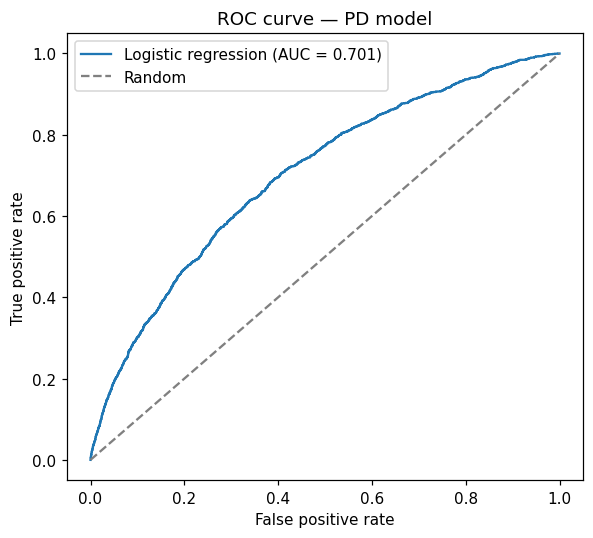

In [6]:
fpr, tpr, _ = roc_curve(y_test, proba)
fig, ax = plt.subplots(figsize=(5.5,5))
ax.plot(fpr, tpr, label=f"Logistic regression (AUC = {auc:.3f})")
ax.plot([0,1],[0,1],"--", color="grey", label="Random")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC curve — PD model")
ax.legend()
plt.tight_layout()
plt.show()


## 4. FICO rating buckets (dynamic programming)

A PD score is continuous; most credit processes need a small number of discrete **rating buckets** instead (like a simplified internal rating scale). Naively slicing FICO into equal-width or equal-frequency bins ignores where default risk actually changes. Instead, `fit_fico_buckets` chooses boundaries that **maximize the total log-likelihood** of the observed defaults, treating each bucket's default count as Binomial(n, p) — solved exactly with dynamic programming over all possible boundary combinations (with a minimum bucket size to avoid overfitting to small, noisy pockets of the score range).

In [7]:
boundaries, rating_table = fit_fico_buckets(
    df["fico_score"], df["default"], n_buckets=8, min_bucket_size=1000
)
rating_table = rating_table.sort_values("fico_min").reset_index(drop=True)
print("Optimal FICO cut points:", boundaries)
print()
print(rating_table.to_string(index=False))
print()
monotonic = rating_table["default_rate"].is_monotonic_decreasing
print(f"Default rate strictly decreases as FICO rises across all {len(rating_table)} ratings: {monotonic}")


Optimal FICO cut points: [564, 592, 616, 652, 676, 698, 762]

 rating  fico_min  fico_max  n_borrowers  n_defaults  default_rate
      8       419       563         1989         553        0.2780
      7       564       591         3392         674        0.1987
      6       592       615         5036         887        0.1761
      5       616       651        11559        1726        0.1493
      4       652       675         8659        1088        0.1256
      3       676       697         7061         737        0.1044
      2       698       761        10606         924        0.0871
      1       762       850         1698          83        0.0489

Default rate strictly decreases as FICO rises across all 8 ratings: True


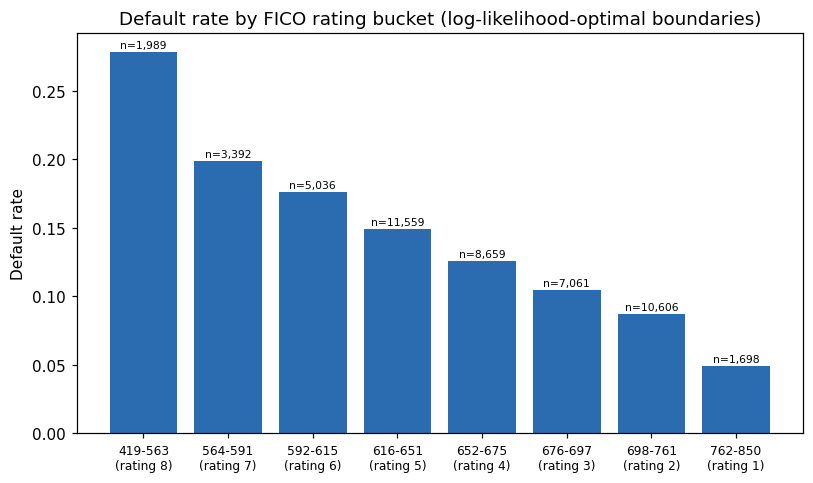

In [8]:
fig, ax = plt.subplots(figsize=(7.5,4.5))
labels = [f"{r.fico_min}-{r.fico_max}\n(rating {r.rating})" for r in rating_table.itertuples()]
bars = ax.bar(labels, rating_table["default_rate"], color="#2b6cb0")
ax.set_ylabel("Default rate")
ax.set_title("Default rate by FICO rating bucket (log-likelihood-optimal boundaries)")
ax.set_xticklabels(labels, rotation=0, fontsize=8)
for b, n in zip(bars, rating_table["n_borrowers"]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003, f"n={n:,}", ha="center", fontsize=7)
plt.tight_layout()
plt.savefig("../outputs/default_rate_by_rating.png")
plt.show()


## 5. Results & business interpretation

Applying the fitted bucket boundaries maps any borrower's raw FICO score to one of the 8 ratings below, ordered from best (1) to worst (8) credit quality by realized default rate.

In [9]:
sample = df.sample(5, random_state=7)[["customer_id","fico_score","default"]].copy()
sample["rating"] = sample["fico_score"].apply(lambda s: assign_rating(s, rating_table))
print(sample.to_string(index=False))

rating_table.to_csv("../outputs/fico_rating_table.csv", index=False)
print("\nSaved rating table to outputs/fico_rating_table.csv")


 customer_id  fico_score  default  rating
       29431         635        0       5
       27751         807        0       1
       47783         656        0       4
       10499         776        0       1
       24748         680        1       3

Saved rating table to outputs/fico_rating_table.csv


### Takeaways

- **PD model (§3):** a 4-feature logistic regression separates defaulters
  from non-defaulters with AUC ≈ 0.70 — a realistic starting point for an
  application-level model, with all coefficients directionally consistent
  with credit-risk theory.
- **Rating buckets (§4):** the dynamic-programming bucketing produces 8
  ratings with a **strictly monotonic** default-rate progression (confirmed
  above), which is the property any usable internal rating scale needs — a
  worse rating should never imply a lower observed default rate.
- **Why DP over naive binning:** equal-width/equal-frequency bins would
  split the score range without reference to where risk actually changes.
  Maximizing bucket-level log-likelihood instead finds boundaries the *data*
  supports, subject to a minimum-size floor that keeps each bucket
  statistically meaningful.

### Limitations
- Data is synthetic; real portfolios need bureau tradeline history, vintage/
  macro controls, and out-of-time validation before any of this would be
  production-ready.
- The PD model is a single linear specification; production PD models
  typically compare several specifications (WOE-binned logistic regression,
  gradient boosting, etc.) and calibrate to a scorecard.
- Rating boundaries were fit and evaluated on data generated from a known
  process here — on real data, boundaries should be fit on a training window
  and validated out-of-time/out-of-sample before use.
